## K562 test set, bpnet architecture


no dup 5' count track: http://mitra.stanford.edu/kundaje/projects/atlas/dnase_processed/atac/09ce5f39-5360-411b-88dd-b86f4a1286a7/call-bam2ta/shard-0/execution/ENCSR000EOT.merged.nodup.tagAlign.gz.counts.unstranded.bw

with dup 5' count track: http://mitra.stanford.edu/kundaje/projects/atlas/dnase_processed/atac/09ce5f39-5360-411b-88dd-b86f4a1286a7/call-bam2ta/shard-0/execution/ENCSR000EOT.merged.nodup.tagAlign.gz.counts.unstranded.bpnet.bw

browser session: 
https://epgg-test.wustl.edu/browser/?genome=hg38&session=bi7RAHiAtD&statusId=538251731

In [3]:
import pandas as pd 
from scipy.stats import spearmanr 
from scipy.stats import pearsonr 
from scipy.special import softmax

## get ranked list of IDR peaks on chrom 1 (test chrom)

In [4]:
## for plotting 
import matplotlib 
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"]=10,5

In [5]:
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 10}

matplotlib.rc('font', **font)

In [6]:
import h5py
import numpy as np

## high weight profile loss 

In [7]:
preds=h5py.File("k562.dnase.with.bpnet.bias.0.predictions",'r')
preds.keys()

<KeysViewHDF5 ['coords', 'lab_0', 'lab_1', 'pred_0', 'pred_1']>

In [8]:
dup_hw_profile_labels_0=np.array(preds[('lab_0')])
dup_hw_profile_labels_1=np.array(preds[('lab_1')])
dup_hw_profile_pred_0=np.array(preds[('pred_0')])
dup_hw_profile_pred_1=np.array(preds[('pred_1')])

In [9]:
dup_hw_profile_pred_1

array([7.3208513, 7.552542 , 8.413282 , ..., 9.635007 , 9.410909 ,
       7.0364094], dtype=float32)

In [10]:
#get counts profile & softmax 
dup_hw_profile_pred_0_softmax=softmax(dup_hw_profile_pred_0,axis=1)

In [11]:
dup_hw_profile_pred_0_softmax.shape

(16586, 1000)

In [12]:
dup_hw_profile_pred_0_count=dup_hw_profile_pred_0_softmax*np.expand_dims(dup_hw_profile_pred_1,axis=1)

In [13]:
dup_hw_profile_labels_0

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  1.,  0.,  0.],
       [ 0.,  0.,  0., ..., 26., 14., 67.],
       ...,
       [94., 33., 10., ...,  0.,  0.,  0.],
       [44., 69., 52., ...,  5.,  3.,  0.],
       [ 1.,  1.,  1., ...,  1.,  1.,  0.]])

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


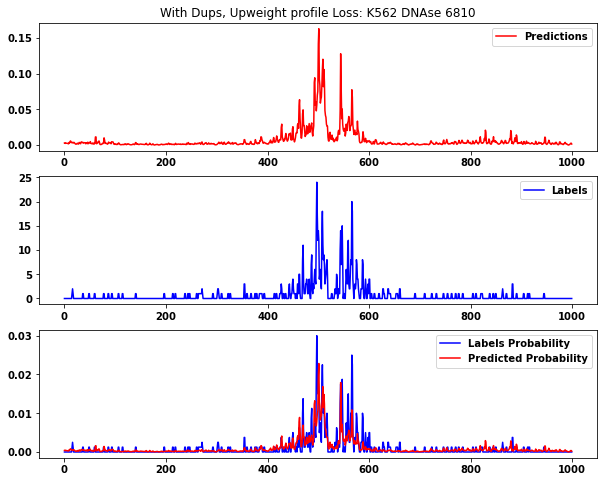

In [14]:
plt.rcParams["figure.figsize"]=10,8
for pos in [6810]:
    fig, axes = plt.subplots(3, 1)
    probs_observed=dup_hw_profile_labels_0[pos]/sum(dup_hw_profile_labels_0[pos])
    axes[0].plot(dup_hw_profile_pred_0_count[pos],label='Predictions',color='r')
    axes[1].plot(dup_hw_profile_labels_0[pos],label='Labels',color='b')
    axes[2].plot(probs_observed,label="Labels Probability",color='b')
    axes[2].plot(dup_hw_profile_pred_0_softmax[pos],label="Predicted Probability",color='r')    
    axes[0].set_title('With Dups, Upweight profile Loss: K562 DNAse '+str(pos))
    axes[0].legend()
    axes[1].legend() 
    axes[2].legend()